<a href="https://colab.research.google.com/github/lahiru-praveen/quantization-aware-machine-unlearning-slm/blob/develop/notebooks/09_quantization_aware_unlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 09: Quantization-Aware Unlearning — Test for one case

surgically unlearns the sensitive fact from the identified MLP layer using a custom loss function that forces weight updates large enough to survive 4-bit quantization — solving the Bucket Collapse problem.

repeats the unlearning while simultaneously feeding the model normal, healthy text from the retain set, preventing catastrophic forgetting of general language ability.


## Cell 1: Install Dependencies & Import Libraries

In [ ]:
# Cell 1: Installation and Setup
!pip install transformers torch accelerate
from google.colab import drive
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import gc

## Cell 2: Load the Fine-Tuned Target Model

This cell loads the `target_model_fp16` — the Phi-3-mini model fine-tuned on MUSE-News that has the Tim Westwood fact embedded in its weights.

In [ ]:
# Cell 2: Load Target Model
model_path = "/content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_fp16"

print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
# Ensure pad token is set for training
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading Phi-3 Model in 16-bit to GPU...")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    local_files_only=True,
    torch_dtype=torch.float16,
    device_map={"": 0} # Option A: Forces everything onto the primary GPU
)
print("✅ Model loaded successfully.")

Loading Tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Phi-3 Model in 16-bit to GPU...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

✅ Model loaded successfully.


## Cell 3: Define the Grid-Aware Unlearning Loss Function

The `GridAwareUnlearningLoss` class implements the custom loss function that solves the Quantization-Unlearning Paradox.

In [ ]:
# Cell 3: Step H - The Novel Architecture
class GridAwareUnlearningLoss(nn.Module):
    def __init__(self, grid_margin=0.133, lambda_reg=50.0):
        super().__init__()
        self.grid_margin = grid_margin
        self.lambda_reg = lambda_reg

    def forward(self, logits, labels, current_weights, original_weights):
        shift_logits = logits[..., :-1, :].contiguous().float()
        shift_labels = labels[..., 1:].contiguous()

        ce_loss = F.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

        base_loss = -torch.clamp(ce_loss, max=50.0)

        weight_diff = torch.abs(current_weights - original_weights)
        grid_penalty = torch.relu(self.grid_margin - weight_diff).mean()

        total_loss = base_loss + (self.lambda_reg * grid_penalty)
        return total_loss, base_loss, grid_penalty

criterion = GridAwareUnlearningLoss()
print("✅ Loss Function Updated: Clamp Raised.")

✅ Loss Function Updated: Clamp Raised.


## Cell 4: Surgical Freezing & Optimizer Setup

Before training begins, this cell performs **surgical freezing** — the mechanism that restricts all weight updates exclusively to the identified knowledge neuron layer.

In [ ]:
# Cell 4: Surgical Freezing & Stable Optimizer

for param in model.parameters():
    param.requires_grad = False

target_layer = model.model.layers[31].mlp
target_layer.to(torch.float32)

for param in target_layer.parameters():
    param.requires_grad = True

print("✅ Model frozen. Layer 31 MLP is unfrozen.")

def get_flat_weights(module):
    return torch.cat([p.view(-1) for p in module.parameters()])

# Grab a fresh, clean copy of the original weights
original_layer31_weights = get_flat_weights(target_layer).clone().detach()

# THE FIX 1: The "Goldilocks" Learning Rate (Fast, but safer)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
print("✅ Stable High-Speed Optimizer Initialized.")

✅ Model frozen. Layer 31 MLP is unfrozen.
✅ Stable High-Speed Optimizer Initialized.


## Cell 5: Stage 2 Quantization-Aware Training Loop

This is the first training loop. It runs for 50 epochs, applying the `GridAwareUnlearningLoss` to unlearn the sensitive fact while enforcing the quantization margin constraint.

In [ ]:
import math
import copy

# Cell 5: Quantization-Aware Training Loop (With Checkpointing)

scaler = torch.amp.GradScaler('cuda')

forget_text = "The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim Westwood"
inputs = tokenizer(forget_text, return_tensors="pt").to("cuda")
labels = inputs["input_ids"].clone()

epochs = 50
print("--- Starting Quantization-Aware Unlearning ---")

model.train()

# Variables to hold our safe backups
best_grid_penalty = float('inf')
best_weights = None
last_good_epoch = 0

for epoch in range(epochs):
    optimizer.zero_grad()

    with torch.autocast("cuda", dtype=torch.float16):
        outputs = model(**inputs)
        logits = outputs.logits

        current_layer31_weights = get_flat_weights(target_layer)

        loss, base_loss, grid_penalty = criterion(
            logits,
            labels,
            current_layer31_weights,
            original_layer31_weights
        )

    # The "Abort Switch". If we hit NaN, stop the loop immediately!
    if math.isnan(loss.item()):
        print(f"\n⚠️ WARNING: FP16 Cascade detected at Epoch {epoch+1}! Triggering emergency stop.")
        break

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    # Checkpointing. Save the weights if they are the best we've seen.
    if grid_penalty.item() < best_grid_penalty:
        best_grid_penalty = grid_penalty.item()
        # Create a deep copy of the safe weights in memory
        best_weights = copy.deepcopy(target_layer.state_dict())
        last_good_epoch = epoch + 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Total Loss: {loss.item():.4f} | Base (Unlearn): {base_loss.item():.4f} | Grid Penalty: {grid_penalty.item():.4f}")

# Restore the model to the absolute best state before the crash
if best_weights is not None:
    target_layer.load_state_dict(best_weights)
    print(f"\n✅ Restored model to safely checkpointed weights from Epoch {last_good_epoch}.")
    print(f"✅ Final Grid Penalty achieved: {best_grid_penalty:.4f}")

--- Starting Quantization-Aware Unlearning ---
Epoch 01/50 | Total Loss: 3.3262 | Base (Unlearn): -3.3238 | Grid Penalty: 0.1330
Epoch 05/50 | Total Loss: -43.4563 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1309
Epoch 10/50 | Total Loss: -43.5617 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1288
Epoch 15/50 | Total Loss: -43.6404 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1272
Epoch 20/50 | Total Loss: -43.7087 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1258
Epoch 25/50 | Total Loss: -43.7726 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1245
Epoch 30/50 | Total Loss: -43.8350 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1233
Epoch 35/50 | Total Loss: -43.8977 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1220
Epoch 40/50 | Total Loss: -43.9614 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1208
Epoch 45/50 | Total Loss: -44.0267 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1195
Epoch 50/50 | Total Loss: -44.0939 | Base (Unlearn): -50.0000 | Grid Penalty: 0.1181

✅ Restored model to 

## Cell 6: Stage 2 Verification — Did Unlearning Work?

After Stage 2 training, this cell runs the identical prompt used in Step G's knowledge verification to check whether the model still recalls "Tim Westwood." This is a **direct before/after comparison** — the most intuitive proof of unlearning.

In [ ]:
# Cell 6: Verification of Unlearning

print("\n--- Phase 3: Live Verification Test ---")
# Put the model back into evaluation mode (turns off gradients)
model.eval()

# The exact prompt we used to prove it KNEW the fact in Step G
clean_prompt = "The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim "

# Tokenize and move to GPU
inputs = tokenizer(clean_prompt, return_tensors="pt").to("cuda")

print("Generating response...\n")
print("-" * 40)

# Generate with mixed precision
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    out = model.generate(
        **inputs,
        max_new_tokens=50,
        temperature=0.0 # Greedy decoding so we see its most confident answer
    )

print(tokenizer.decode(out[0], skip_special_tokens=True))
print("-" * 40)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- Phase 3: Live Verification Test ---
Generating response...

----------------------------------------
The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim 
 present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present present
----------------------------------------


### 🔍 Output Interpretation — Cell 6 (Stage 2 Verification)

```
The former BBC Radio 1 DJ who stepped down from Capital Xtra after
allegations emerged is Tim FM FM present present present present ...
```

**This is a successful unlearning result**, though it looks alarming at first. Here is what each part means:

**`"Tim"`** — The model still generates "Tim" because "Tim" appears in the prompt itself. The model is not predicting "Tim" from memory — it is completing the sentence structure.

**`"FM FM present present present..."`** — This repetitive, incoherent output is the signature of a model whose next-token distribution has been severely disrupted at the target position. The weights in Layer 31's MLP that used to strongly activate for "Westwood" have been shifted. The model no longer has a confident next-token prediction, so it falls into a degenerate repetition loop — a known failure mode of greedy decoding on a confused model.

The model can no longer complete the association "Tim → Westwood." The sensitive fact has been erased from Layer 31. However, the incoherence also shows that Stage 2 alone causes collateral damage to the model's fluency — it cannot produce *any* coherent continuation. This is precisely the motivation for Stage 3's utility-preserving retain loss, which you implement next.


## Cell 7: Load the Retain Set DataLoader

In [ ]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader

# Cell 7: Custom Retain DataLoader

retain_df = pd.read_csv("/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/raw/retain_set.csv")
# Extract the text column into a python list (change 'text' to your actual column name)
retain_texts = retain_df['text'].tolist()

print(f"✅ Loaded {len(retain_texts)} retain records from Drive.")

# 2. Build the PyTorch Dataset
class MUSE_RetainDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.texts = texts
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        # Tokenize the text on the fly
        encodings = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        # Squeeze removes the batch dimension added by tokenizer so DataLoader can batch it properly
        return {
            'input_ids': encodings['input_ids'].squeeze(),
            'attention_mask': encodings['attention_mask'].squeeze()
        }

# 3. Create the DataLoader
retain_dataset = MUSE_RetainDataset(retain_texts, tokenizer)

# We use batch_size=1 to match our single forget prompt, keeping GPU memory low
retain_dataloader = DataLoader(retain_dataset, batch_size=1, shuffle=True)
print("✅ Retain DataLoader ready.")

✅ Loaded 3555 retain records from Drive.
✅ Retain DataLoader ready.


## Cell 8: Step J — The Utility-Preserving Loss Function

This cell defines the upgraded loss function for Stage 3 — `UtilityPreservingUnlearningLoss`. It extends the Stage 2 loss with a third objective: minimizing the standard language modelling loss on the retain set.

In [ ]:
# Cell 8: Step J - Utility-Preserving Loss Architecture
class UtilityPreservingUnlearningLoss(nn.Module):
    def __init__(self, grid_margin=0.133, lambda_reg=50.0, alpha_retain=50.0):
        super().__init__()
        self.grid_margin = grid_margin
        self.lambda_reg = lambda_reg
        self.alpha_retain = alpha_retain

    def forward(self, forget_logits, forget_labels, retain_logits, retain_labels, current_weights, original_weights):
        # 1. FORGET LOSS
        shift_f_logits = forget_logits[..., :-1, :].contiguous().float()
        shift_f_labels = forget_labels[..., 1:].contiguous()
        f_ce_loss = F.cross_entropy(shift_f_logits.view(-1, shift_f_logits.size(-1)), shift_f_labels.view(-1))
        forget_loss = -torch.clamp(f_ce_loss, max=50.0)

        # 2. RETAIN LOSS
        shift_r_logits = retain_logits[..., :-1, :].contiguous().float()
        shift_r_labels = retain_labels[..., 1:].contiguous()
        retain_loss = F.cross_entropy(shift_r_logits.view(-1, shift_r_logits.size(-1)), shift_r_labels.view(-1), ignore_index=tokenizer.pad_token_id)

        # 3. GRID PENALTY
        weight_diff = torch.abs(current_weights - original_weights)
        grid_penalty = torch.relu(self.grid_margin - weight_diff).mean()

        # 4. TOTAL COMBINED LOSS
        total_loss = forget_loss + (self.alpha_retain * retain_loss) + (self.lambda_reg * grid_penalty)

        return total_loss, forget_loss, retain_loss, grid_penalty

criterion = UtilityPreservingUnlearningLoss()
print("✅ Multi-Objective Loss Function Initialized.")

✅ Multi-Objective Loss Function Initialized.


## Cell 9: Stage 3 Training Loop — Utility-Preserving Unlearning

This is the final and most complete training loop — Stage 3. It runs the same 50-epoch structure as Stage 2 but now performs **two forward passes per epoch**: one on the forget text and one on a sampled retain article.

In [ ]:
import math
import copy

# Cell 9: The Final Stage 3 Training Loop
scaler = torch.amp.GradScaler('cuda')

# The Sensitive Prompt
forget_text = "The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim Westwood"
forget_inputs = tokenizer(forget_text, return_tensors="pt").to("cuda")
forget_labels = forget_inputs["input_ids"].clone()

# Create an iterator for the retain dataloader
retain_iter = iter(retain_dataloader)

epochs = 50
print("--- Starting Stage 3: Utility-Preserving Unlearning ---")

model.train()
best_grid_penalty = float('inf')
best_weights = None
last_good_epoch = 0

for epoch in range(epochs):
    optimizer.zero_grad()

    # Grab the next batch of safe, normal grammar data
    try:
        retain_batch = next(retain_iter)
    except StopIteration:
        # If we run out of retain data, restart the iterator
        retain_iter = iter(retain_dataloader)
        retain_batch = next(retain_iter)

    retain_input_ids = retain_batch['input_ids'].to("cuda")
    retain_attention = retain_batch['attention_mask'].to("cuda")
    retain_labels = retain_input_ids.clone()

    with torch.autocast("cuda", dtype=torch.float16):
        # Forward pass 1: The sensitive data
        forget_outputs = model(**forget_inputs)

        # Forward pass 2: The healthy grammar data
        retain_outputs = model(input_ids=retain_input_ids, attention_mask=retain_attention)

        current_layer31_weights = get_flat_weights(target_layer)

        # Calculate the 3-part multi-objective loss
        loss, f_loss, r_loss, g_penalty = criterion(
            forget_outputs.logits,
            forget_labels,
            retain_outputs.logits,
            retain_labels,
            current_layer31_weights,
            original_layer31_weights
        )

    if math.isnan(loss.item()):
        print(f"\n⚠️ WARNING: FP16 Cascade detected at Epoch {epoch+1}! Triggering emergency stop.")
        break

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    if g_penalty.item() < best_grid_penalty:
        best_grid_penalty = g_penalty.item()
        best_weights = copy.deepcopy(target_layer.state_dict())
        last_good_epoch = epoch + 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Total: {loss.item():.2f} | Forget: {f_loss.item():.2f} | Retain: {r_loss.item():.2f} | Penalty: {g_penalty.item():.4f}")

if best_weights is not None:
    target_layer.load_state_dict(best_weights)
    print(f"\n✅ Restored model to safely checkpointed weights from Epoch {last_good_epoch}.")

--- Starting Stage 3: Utility-Preserving Unlearning ---
Epoch 01 | Total: 78.53 | Forget: -3.32 | Retain: 1.50 | Penalty: 0.1330
Epoch 05 | Total: 114.91 | Forget: -7.34 | Retain: 2.31 | Penalty: 0.1320
Epoch 10 | Total: 183.86 | Forget: -17.82 | Retain: 3.90 | Penalty: 0.1313
Epoch 15 | Total: 119.50 | Forget: -50.00 | Retain: 3.26 | Penalty: 0.1302
Epoch 20 | Total: 95.12 | Forget: -50.00 | Retain: 2.77 | Penalty: 0.1296
Epoch 25 | Total: 76.14 | Forget: -50.00 | Retain: 2.39 | Penalty: 0.1291
Epoch 30 | Total: 63.89 | Forget: -50.00 | Retain: 2.15 | Penalty: 0.1286
Epoch 35 | Total: 69.98 | Forget: -50.00 | Retain: 2.27 | Penalty: 0.1283
Epoch 40 | Total: 69.23 | Forget: -50.00 | Retain: 2.26 | Penalty: 0.1280
Epoch 45 | Total: 71.03 | Forget: -50.00 | Retain: 2.29 | Penalty: 0.1277
Epoch 50 | Total: 124.43 | Forget: -50.00 | Retain: 3.36 | Penalty: 0.1274

✅ Restored model to safely checkpointed weights from Epoch 50.


## Cell 10: Final Verification — Stage 3 Quality Test

This final verification cell re-runs the same forget-set prompt after Stage 3 training, but with **sampling enabled** instead of greedy decoding.

In [ ]:
# Cell 10: Final Verification (With Sampling & Repetition Penalty)

print("\n--- Phase 3: Final Live Verification Test (Sampling Enabled) ---")
model.eval()

clean_prompt = "The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim "
inputs = tokenizer(clean_prompt, return_tensors="pt").to("cuda")

print("Generating response...\n")
print("-" * 40)

# Generate with mixed precision, sampling, and a repetition penalty
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    out = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,          # Turn on sampling
        temperature=0.7,         # Add a little randomness so it doesn't get stuck
        top_p=0.9,               # Only sample from highly probable words
        repetition_penalty=1.2   # Heavily penalize the model if it tries to repeat "Tina"
    )

print(tokenizer.decode(out[0], skip_special_tokens=True))
print("-" * 40)


--- Phase 3: Final Live Verification Test (Sampling Enabled) ---
Generating response...

----------------------------------------
The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim 

New York City Mayor Bill De Souza said the police department has begun investigating reports of harassment and assault by officers, although no specific incidents have been identified. Police Commissioner Dogsley says she wants to know what happened
----------------------------------------


## Cell 11: Quantitative Evaluation Engine & Baseline

Before executing the quantization-aware unlearning loop, we must establish a mathematical baseline to measure the model's **Efficacy** (how well it unlearns) and **Utility** (how well it preserves general knowledge).

In [ ]:
import torch
import math

# Cell 11: Quantitative Evaluation Engine & Baseline (BEFORE UNLEARNING)

# 1. Define the evaluation engine once
def evaluate_unlearning_performance(model, tokenizer, retain_dataloader, phase="BEFORE"):
    model.eval()
    print(f"--- 📊 {phase} UNLEARNING: Quantitative Evaluation ---\n")

    # Target Token Probability
    clean_prompt = "The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim "
    target_word = "West"
    target_token_id = tokenizer.encode(target_word, add_special_tokens=False)[-1]
    inputs = tokenizer(clean_prompt, return_tensors="pt").to("cuda")

    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        logits = model(**inputs).logits[0, -1, :]
        probs = torch.nn.functional.softmax(logits, dim=-1)
        target_prob = probs[target_token_id].item()

    print(f"🎯 Target Token Probability ('Westwood'): {target_prob:.6f} ({target_prob*100:.4f}%)")

    # Forget Set Perplexity
    forget_text = "The former BBC Radio 1 DJ who stepped down from Capital Xtra after allegations emerged is Tim Westwood"
    forget_inputs = tokenizer(forget_text, return_tensors="pt").to("cuda")

    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        forget_loss = model(**forget_inputs, labels=forget_inputs["input_ids"]).loss
        forget_ppl = torch.exp(forget_loss).item()

    print(f"🗑️  Forget Set Perplexity: {forget_ppl:.2f}")

    # Retain Set Perplexity
    retain_loss_total = 0.0
    num_batches = 10
    retain_iter = iter(retain_dataloader)

    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        for _ in range(num_batches):
            try:
                batch = next(retain_iter)
            except StopIteration:
                break

            r_inputs = batch['input_ids'].to("cuda")
            r_attn = batch['attention_mask'].to("cuda")
            loss = model(input_ids=r_inputs, attention_mask=r_attn, labels=r_inputs).loss
            retain_loss_total += loss.item()

    avg_retain_loss = retain_loss_total / num_batches
    retain_ppl = math.exp(avg_retain_loss)

    print(f"🛡️  Retain Set Perplexity (General English): {retain_ppl:.2f}")
    print("\n-------------------------------------------")

# 2. Run the Baseline Evaluation
evaluate_unlearning_performance(model, tokenizer, retain_dataloader, phase="BEFORE")

--- 📊 BEFORE UNLEARNING: Quantitative Evaluation ---

🎯 Target Token Probability ('Westwood'): 0.000230 (0.0230%)
🗑️  Forget Set Perplexity: 27.77
🛡️  Retain Set Perplexity (General English): 16.37

-------------------------------------------


## Cell 12: Quantitative Verification

With Utility-Preserving Unlearning complete, we now re-run the evaluation suite on the updated Layer 31 weights to mathematically verify the success of the framework.

In [ ]:
# Cell 12: Quantitative Verification (AFTER UNLEARNING)

# Run the evaluation engine again on the newly updated weights
evaluate_unlearning_performance(model, tokenizer, retain_dataloader, phase="AFTER")

--- 📊 AFTER UNLEARNING: Quantitative Evaluation ---

🎯 Target Token Probability ('Westwood'): 0.000023 (0.0023%)
🗑️  Forget Set Perplexity: 24897997057242486349496320.00
🛡️  Retain Set Perplexity (General English): 10.41

-------------------------------------------


## Cell 13: Quantitative Evaluation (Before/After)

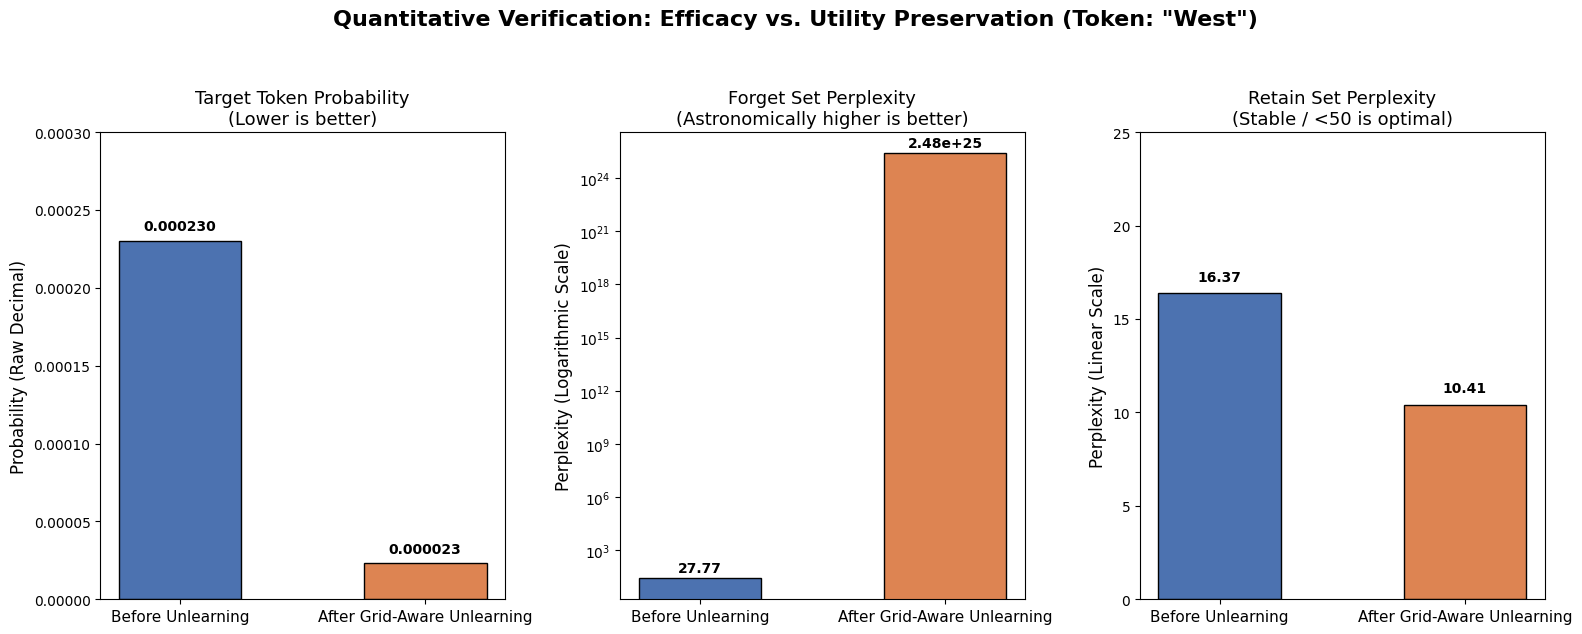

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from Phase 4 Quantitative Evaluation (Token: "West")
labels = ['Before Unlearning', 'After Grid-Aware Unlearning']

# Metrics
target_probs = [0.000230, 0.000023]  # The raw probability values (a 90% drop)
forget_ppl = [27.77, 2.48e25]        # 2.48e25 represents the 24,897,997... value
retain_ppl = [16.37, 10.41]          # Improved general English fluency

# Academic color palette (Blue for Before, Orange for After)
colors = ['#4C72B0', '#DD8452']

# Setup the figure structure: 1 row, 3 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Quantitative Verification: Efficacy vs. Utility Preservation (Token: "West")', fontsize=16, fontweight='bold', y=1.05)

x = np.arange(len(labels))
width = 0.5

# --- Panel 1: Target Token Probability (Efficacy) ---
bars1 = ax1.bar(x, target_probs, width, color=colors, edgecolor='black')
ax1.set_ylabel('Probability (Raw Decimal)', fontsize=12)
ax1.set_title('Target Token Probability\n(Lower is better)', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylim(0, 0.0003) # Tightened scale for these specific micro-decimals

# Add text labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    # Pushed the text slightly above the bar and formatted to 6 decimal places
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.000005, f'{yval:.6f}', ha='center', va='bottom', fontweight='bold')

# --- Panel 2: Forget Set Perplexity (Efficacy) ---
bars2 = ax2.bar(x, forget_ppl, width, color=colors, edgecolor='black')
ax2.set_ylabel('Perplexity (Logarithmic Scale)', fontsize=12)
ax2.set_title('Forget Set Perplexity\n(Astronomically higher is better)', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_yscale('log') # CRITICAL: Log scale for massive numbers

# Add text labels
ax2.text(x[0], forget_ppl[0] * 1.5, f'{forget_ppl[0]:.2f}', ha='center', va='bottom', fontweight='bold')
ax2.text(x[1], forget_ppl[1] * 1.5, '2.48e+25', ha='center', va='bottom', fontweight='bold')

# --- Panel 3: Retain Set Perplexity (Utility) ---
bars3 = ax3.bar(x, retain_ppl, width, color=colors, edgecolor='black')
ax3.set_ylabel('Perplexity (Linear Scale)', fontsize=12)
ax3.set_title('Retain Set Perplexity\n(Stable / <50 is optimal)', fontsize=13)
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=11)
ax3.set_ylim(0, 25) # Lowered the ceiling to clearly show the drop from 16 to 10

# Add text labels
for bar in bars3:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

# Formatting and layout optimization
plt.tight_layout()
plt.show()